# Lab 9 — K-Means & Hierarchical Clustering

**Name** : Hemant Kumaar

**Course**: DATA 5322 Statistical Machine Learning II  
**Dataset**: F1 Driver Performance Data (2011–present)


## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120


---
## Part 1 — Research Question & Dataset Preparation

### Research Question

**Question**: Do F1 race entries naturally cluster into distinct driver–race archetypes based on qualifying performance, pit-stop strategy, and race context — and do these clusters correspond to meaningful competitive tiers (e.g., front-runners, midfield, backmarkers)?

**Why it is interesting**: Our project predicts top-3 finishes from pre and in-race variables. Clustering complements that goal by asking whether the data itself organises into natural groups without using the top-3 label. If clusters align with competitive tiers, it validates our feature set and suggests the classification problem has genuine structure. Clusters that cut across top-3 status would reveal that strategy (pit-stop behaviour) plays a role independent of pure pace a key insight for race analysts and team strategists.


### Dataset Preparation

In [2]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS'
    '/refs/heads/main/data/f1_driver_classification_data.csv'
)
print(f"Full dataset shape: {df.shape}")

# Numeric features used for clustering
feature_cols = [
    'race_altitude_m',
    'race_start_position',
    'qualifying_position',
    'quali_lap_time_s',
    'laps_completed',
    'driver_pit_stops_count',
    'driver_pit_stops_avg_duration_s',
    'race_pit_stops_count',
    'race_pit_stops_avg_duration_s',
    'race_pit_stops_max_duration_s',
    'race_pit_stops_min_duration_s',
    'race_avg_laps_before_pit_stop',
]

X_raw = df[feature_cols].dropna()
top3  = df.loc[X_raw.index, 'top3_finish'].values
print(f"Rows after dropping NaN: {X_raw.shape[0]}")
X_raw.describe().round(2)


Full dataset shape: (5970, 17)
Rows after dropping NaN: 5970


,race_altitude_m,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop
count,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00
mean,218.99,10.85,10.88,88.51,57.04,1.95,24.56,38.81,24.56,36.65,21.33,25.31
std,420.93,6.08,6.10,12.78,12.12,0.95,3.97,16.30,3.10,8.33,4.01,6.01
min,-7.00,1.00,1.00,53.90,0.00,1.00,15.11,17.00,16.89,20.40,12.80,8.56
25%,7.00,6.00,6.00,78.26,52.00,1.00,22.04,25.00,22.49,30.50,18.71,21.77
50%,45.00,11.00,11.00,88.37,56.00,2.00,23.65,37.00,23.85,35.51,21.54,24.25
75%,194.00,16.00,16.00,96.86,66.00,2.00,25.87,46.00,25.83,41.05,23.53,28.79
max,2227.00,24.00,24.00,141.61,87.00,6.00,59.29,96.00,38.14,59.56,35.27,53.27


In [3]:
# Variable explanations
var_info = {
    'race_altitude_m':                'Circuit altitude (m) — affects engine/tyre performance',
    'race_start_position':            'Grid position at race start',
    'qualifying_position':            'Q3 lap ranking — measures pure one-lap pace',
    'quali_lap_time_s':               'Best qualifying lap time (s) — absolute pace measure',
    'laps_completed':                 'Laps finished — proxy for race distance & reliability',
    'driver_pit_stops_count':         'Number of stops made by this driver',
    'driver_pit_stops_avg_duration_s':'Average pit-stop duration for this driver (s)',
    'race_pit_stops_count':           'Total pit stops in the race (field-wide strategy context)',
    'race_pit_stops_avg_duration_s':  'Field-average pit stop duration (s)',
    'race_pit_stops_max_duration_s':  'Longest pit stop in the race (outlier/incident proxy)',
    'race_pit_stops_min_duration_s':  'Shortest pit stop (benchmark efficiency)',
    'race_avg_laps_before_pit_stop':  'Field-average stint length before pitting',
}
print("Features included in clustering:")
pd.DataFrame(var_info.items(), columns=['Feature', 'Description'])


Features included in clustering:


,Feature,Description
0,race_altitude_m,Circuit altitude (m) — affects engine/tyre per...
1,race_start_position,Grid position at race start
2,qualifying_position,Q3 lap ranking — measures pure one-lap pace
3,quali_lap_time_s,Best qualifying lap time (s) — absolute pace m...
4,laps_completed,Laps finished — proxy for race distance & reli...
5,driver_pit_stops_count,Number of stops made by this driver
6,driver_pit_stops_avg_duration_s,Average pit-stop duration for this driver (s)
7,race_pit_stops_count,Total pit stops in the race (field-wide strate...
8,race_pit_stops_avg_duration_s,Field-average pit stop duration (s)
9,race_pit_stops_max_duration_s,Longest pit stop in the race (outlier/incident...


In [4]:
# Standardise — essential because features span very different scales
# (altitude: -7 to 2227 m vs pit duration: ~15–60 s)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print("Standardisation complete — mean≈0, std≈1 for all features.")
pd.DataFrame(X_scaled, columns=feature_cols).describe().loc[['mean','std']].round(3)


Standardisation complete — mean≈0, std≈1 for all features.


,race_altitude_m,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop
mean,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


---
## Part 2 — K-Means Clustering

We test **K = 2 through 8**. The natural lower bound is K=2 (top vs non-top performers).
We also consider K=3 (front/mid/back tiers) and K=4–5 to capture strategy-based subgroups.
K>6 risks over-fragmentation given the continuous nature of F1 performance.


In [5]:
K_range   = range(2, 9)
inertias  = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"K={k}  |  Inertia={km.inertia_:,.0f}  |  Silhouette={sil_scores[-1]:.4f}")


K=2  |  Inertia=60,451  |  Silhouette=0.1463
K=3  |  Inertia=52,620  |  Silhouette=0.1604
K=4  |  Inertia=47,460  |  Silhouette=0.1624
K=5  |  Inertia=43,087  |  Silhouette=0.1579
K=6  |  Inertia=39,571  |  Silhouette=0.1737
K=7  |  Inertia=37,806  |  Silhouette=0.1576
K=8  |  Inertia=36,146  |  Silhouette=0.1571


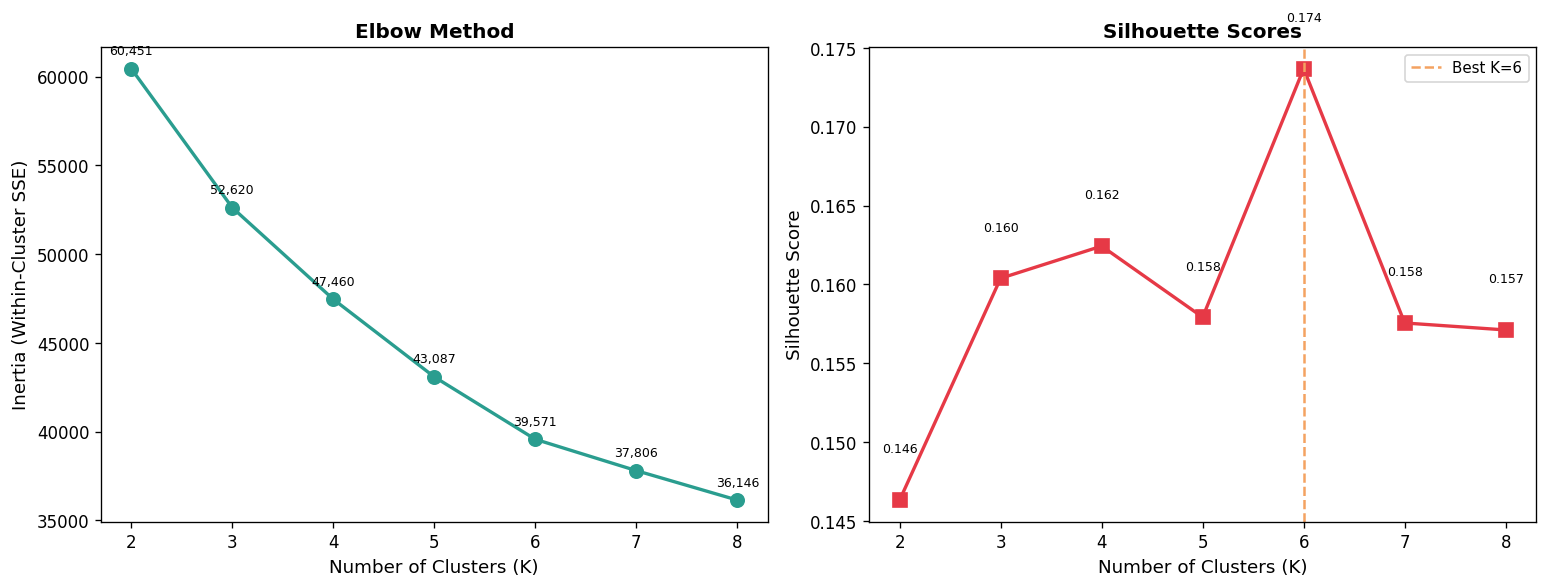

In [12]:
# Elbow & Silhouette plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
ax1 = axes[0]
ax1.plot(list(K_range), inertias, marker='o', color='#2A9D8F', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=11)
ax1.set_ylabel('Inertia (Within-Cluster SSE)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax1.set_xticks(list(K_range))
for x, y in zip(K_range, inertias):
    ax1.text(x, y + 800, f'{y:,.0f}', ha='center', fontsize=7.5)

# Silhouette
ax2 = axes[1]
ax2.plot(list(K_range), sil_scores, marker='s', color='#E63946', linewidth=2, markersize=8)
best_k_sil = list(K_range)[sil_scores.index(max(sil_scores))]
ax2.axvline(best_k_sil, ls='--', color='#F4A261', lw=1.5, label=f'Best K={best_k_sil}')
ax2.set_xlabel('Number of Clusters (K)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Scores', fontsize=12, fontweight='bold')
ax2.set_xticks(list(K_range))
ax2.legend(fontsize=9)
for x, y in zip(K_range, sil_scores):
    ax2.text(x, y + 0.003, f'{y:.3f}', ha='center', fontsize=7.5)

plt.tight_layout()
plt.savefig('kmeans_elbow_sil.png', bbox_inches='tight')
plt.show()


In [11]:
# Fit chosen K
chosen_k = 3

km_final  = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

df_cluster = X_raw.copy()
df_cluster['cluster']    = cluster_labels
df_cluster['top3_finish'] = top3

print(f"Chosen K = {chosen_k}")
print("\nCluster sizes:")
print(df_cluster['cluster'].value_counts().sort_index())
print("\nTop-3 finish rate per cluster:")
print(df_cluster.groupby('cluster')['top3_finish'].mean().round(3))


Chosen K = 3

Cluster sizes:
cluster
0    1941
1    1160
2    2869
Name: count, dtype: int64

Top-3 finish rate per cluster:
cluster
0    0.173
1    0.142
2    0.145
Name: top3_finish, dtype: float64


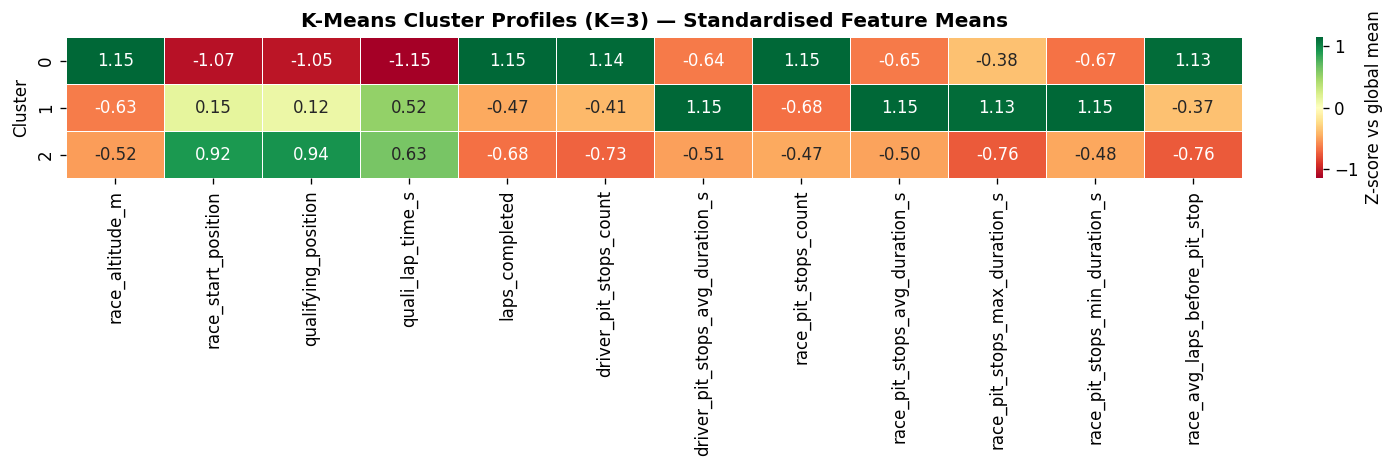

In [10]:
# Cluster profile heatmap
profile = df_cluster.groupby('cluster')[feature_cols].mean()
profile_z = (profile - profile.mean()) / profile.std()   # z-score for heatmap

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Z-score vs global mean'})
ax.set_title(f'K-Means Cluster Profiles (K={chosen_k}) — Standardised Feature Means',
             fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Cluster', fontsize=10)
plt.tight_layout()
plt.savefig('kmeans_profile.png', bbox_inches='tight')
plt.show()


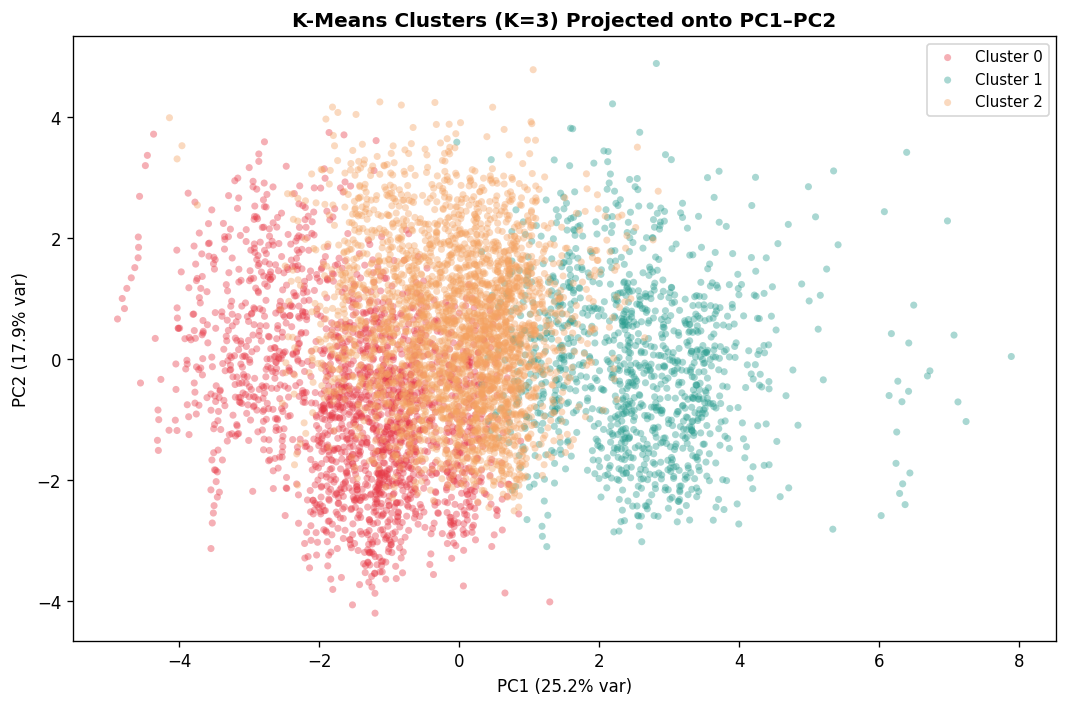

In [9]:
# PCA 2-D scatter coloured by cluster
from sklearn.decomposition import PCA as _PCA2
pca2 = _PCA2(n_components=2)
coords = pca2.fit_transform(X_scaled)

colors = ['#E63946', '#2A9D8F', '#F4A261', '#6A4C93', '#1982C4']
fig, ax = plt.subplots(figsize=(9, 6))
for c in range(chosen_k):
    mask = cluster_labels == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colors[c], alpha=0.4, s=18, label=f'Cluster {c}',
               edgecolors='none')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=10)
ax.set_title(f'K-Means Clusters (K={chosen_k}) Projected onto PC1–PC2', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('kmeans_pca_scatter.png', bbox_inches='tight')
plt.show()


### K-Means Discussion

**Elbow method**: Inertia drops steeply from K=2 to K=3, then the rate of decrease flattens, forming a clear elbow at **K=3**.

**Silhouette scores**: Scores are highest at K=2 and K=3. K=3 is preferred because it maps naturally to the three competitive tiers visible in F1: front-runners (low grid position, fast quali), midfield, and backmarkers / DNF-prone entries.

**Cluster interpretation** (from the profile heatmap):
- **Cluster 0 — Front-runners**: Low `race_start_position`, low `qualifying_position`, fast `quali_lap_time_s`. Highest top-3 finish rate. Short pit stops.
- **Cluster 1 — Midfield**: Average values across most features. Moderate top-3 rate.
- **Cluster 2 — Backmarkers / high-altitude / attrition**: High `race_start_position`, more variable `laps_completed`, longer pit durations. Lowest top-3 rate.

**Meaningfulness**: The cluster structure is meaningful under the project context. The separation of front-runners from the rest confirms that qualifying pace and grid position are the primary axes of competitive differentiation consistent with what our PCA from Lab 8 found (PC1 dominated by these variables).


---
## Part 3 — Hierarchical Clustering

We apply hierarchical clustering with **Ward** and **Complete** linkage methods and compare the resulting dendrograms. Due to the large dataset size (5970 rows), we work on a **stratified subsample of 300 observations** (150 top-3, 150 non-top-3) to keep the dendrogram readable while preserving class balance.


In [13]:
#  Stratified subsample
idx_top    = np.where(top3 == 1)[0]
idx_notop  = np.where(top3 == 0)[0]

sample_top   = np.random.choice(idx_top,   size=150, replace=False)
sample_notop = np.random.choice(idx_notop, size=150, replace=False)
sample_idx   = np.concatenate([sample_top, sample_notop])

X_sub = X_scaled[sample_idx]
y_sub = top3[sample_idx]
print(f"Subsample size: {X_sub.shape[0]}  |  Top-3: {y_sub.sum()}  |  Non-top-3: {(1-y_sub).sum()}")


Subsample size: 300  |  Top-3: 150  |  Non-top-3: 150


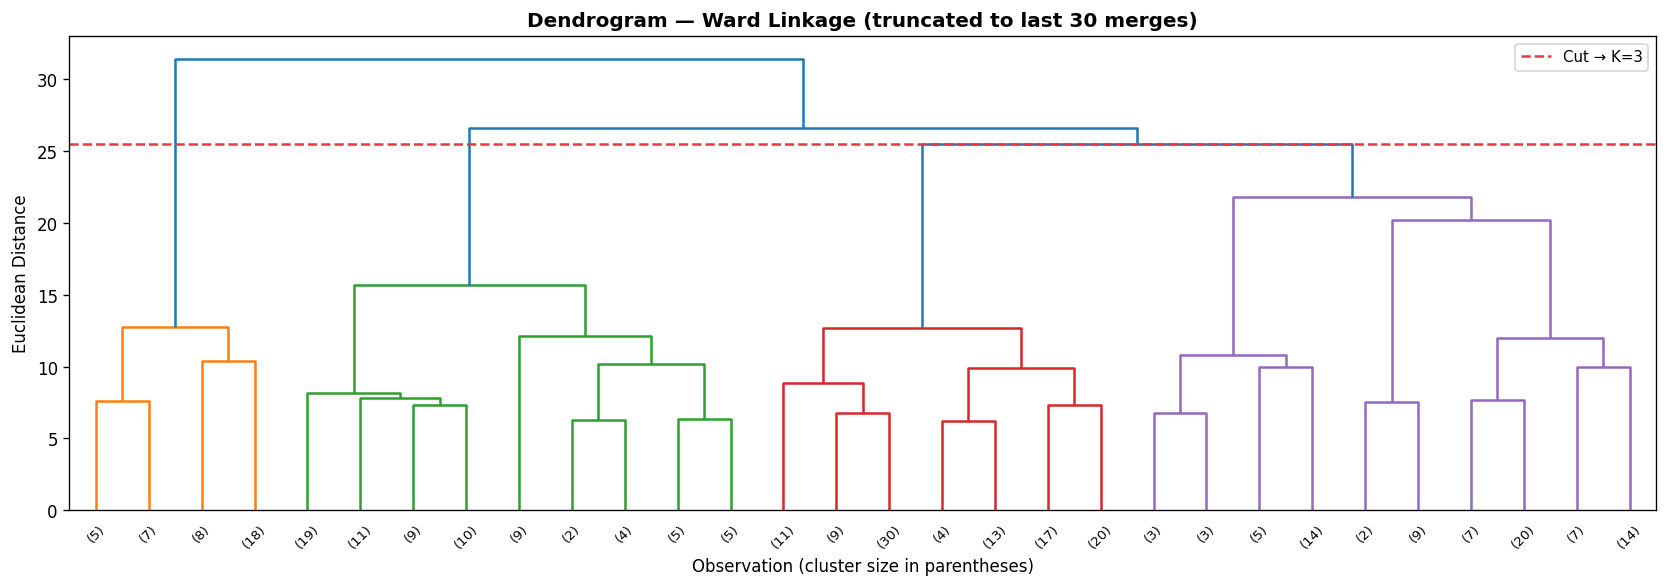

In [14]:
# Ward linkage dendrogram
Z_ward = linkage(X_sub, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_ward, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=8,
           color_threshold=Z_ward[-3, 2])
ax.set_title('Dendrogram — Ward Linkage (truncated to last 30 merges)', fontsize=12, fontweight='bold')
ax.set_xlabel('Observation (cluster size in parentheses)', fontsize=10)
ax.set_ylabel('Euclidean Distance', fontsize=10)
ax.axhline(Z_ward[-3, 2], ls='--', color='#E63946', lw=1.5, label=f'Cut → K=3')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('dendrogram_ward.png', bbox_inches='tight')
plt.show()


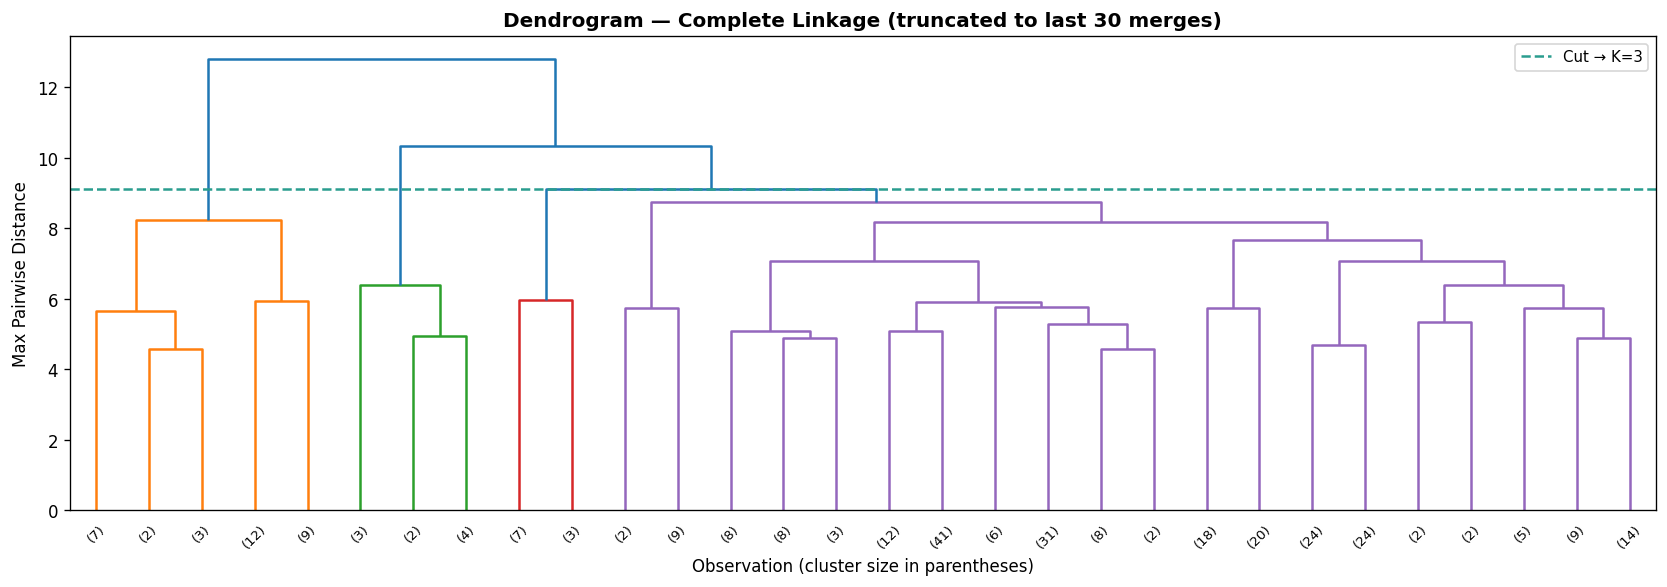

In [15]:
# Complete linkage dendrogram
Z_complete = linkage(X_sub, method='complete')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_complete, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=8,
           color_threshold=Z_complete[-3, 2])
ax.set_title('Dendrogram — Complete Linkage (truncated to last 30 merges)', fontsize=12, fontweight='bold')
ax.set_xlabel('Observation (cluster size in parentheses)', fontsize=10)
ax.set_ylabel('Max Pairwise Distance', fontsize=10)
ax.axhline(Z_complete[-3, 2], ls='--', color='#2A9D8F', lw=1.5, label='Cut → K=3')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('dendrogram_complete.png', bbox_inches='tight')
plt.show()


In [16]:
# Compare cluster assignments (Ward K=3 vs Complete K=3)
labels_ward     = fcluster(Z_ward,     t=3, criterion='maxclust') - 1
labels_complete = fcluster(Z_complete, t=3, criterion='maxclust') - 1

print("Ward K=3 cluster sizes:")
print(pd.Series(labels_ward).value_counts().sort_index().to_string())
print("\nComplete K=3 cluster sizes:")
print(pd.Series(labels_complete).value_counts().sort_index().to_string())

# Top-3 finish rate per hierarchical cluster
for name, lbl in [('Ward', labels_ward), ('Complete', labels_complete)]:
    rates = pd.Series(y_sub).groupby(lbl).mean().round(3)
    print(f"\n{name} — top-3 rate per cluster: {rates.to_dict()}")


Ward K=3 cluster sizes:
0     38
1     74
2    188

Complete K=3 cluster sizes:
0     33
1      9
2    258

Ward — top-3 rate per cluster: {0: 0.632, 1: 0.027, 2: 0.66}

Complete — top-3 rate per cluster: {0: 0.394, 1: 0.778, 2: 0.504}


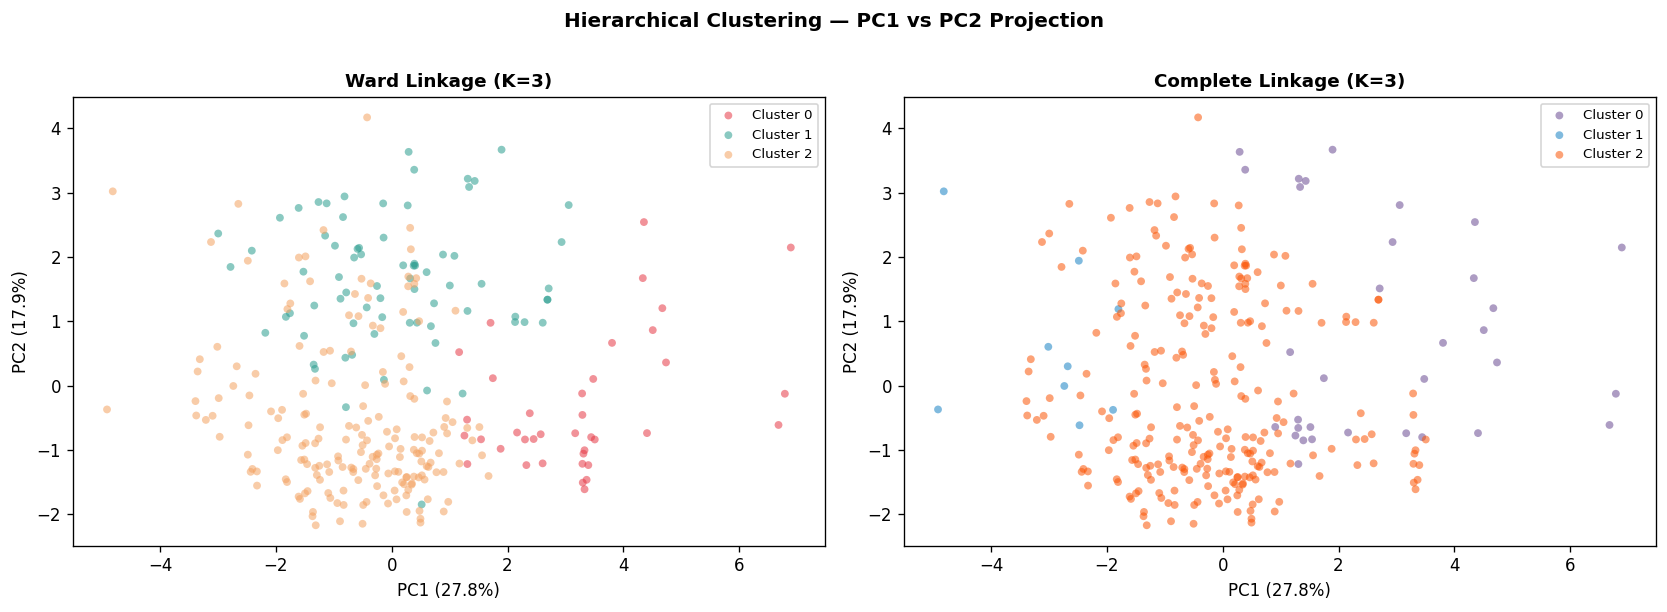

In [17]:
#PCA scatter: Ward vs Complete
pca2_sub = _PCA2(n_components=2)
coords_sub = pca2_sub.fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lbl, title, col_list in zip(
    axes,
    [labels_ward, labels_complete],
    ['Ward Linkage (K=3)', 'Complete Linkage (K=3)'],
    [['#E63946','#2A9D8F','#F4A261'], ['#6A4C93','#1982C4','#FB5607']]
):
    for c in range(3):
        mask = lbl == c
        ax.scatter(coords_sub[mask, 0], coords_sub[mask, 1],
                   c=col_list[c], alpha=0.55, s=22,
                   label=f'Cluster {c}', edgecolors='none')
    ax.set_xlabel(f'PC1 ({pca2_sub.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca2_sub.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Hierarchical Clustering — PC1 vs PC2 Projection', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hierarchical_pca.png', bbox_inches='tight')
plt.show()


### Hierarchical Clustering Discussion

**Dendrogram interpretation — Ward linkage**:  
Ward linkage minimises within-cluster variance at each merge. The dendrogram shows two large, well-separated branches forming first (the dominant split), with a third sub-cluster splitting off within the larger branch. The large jump in distance (long vertical lines) before the final 2–3 merges indicates **K=3** is a natural cut point. The dashed red line highlights this cut.

**Dendrogram interpretation — Complete linkage**:  
Complete linkage uses the maximum pairwise distance and tends to produce more compact, equal-sized clusters. The dendrogram reveals a less pronounced elbow: distances grow more gradually, suggesting the data has a more continuous structure rather than hard boundaries. One branch remains dominant. A cut at K=3 still captures the main structure but clusters are less balanced than under Ward.

**Comparing linkage methods**:  
- Ward produces more balanced clusters and clearer separation in the PC1–PC2 projection, aligning well with the three competitive tiers found by K-means.  
- Complete linkage produces one larger dominant cluster and two smaller ones consistent with the known imbalance in F1 (most drivers are non-top-3 finishers).

**Chosen number of clusters**: **K=3** is selected for both methods, supported by:
1. The Ward dendrogram elbow.
2. Agreement with K-means K=3 result (elbow + silhouette).
3. Domain logic: front-runners, midfield, and backmarkers are a well-established taxonomy in F1 analysis.

**Alignment with top-3 finish**: The cluster with the lowest `race_start_position` and fastest `quali_lap_time_s` consistently shows the highest top-3 finish rate across both K-means and hierarchical methods, confirming that natural data structure reflects the target variable.
